# Universal Studios Singapore Wait Time Analysis

This notebook analyzes attraction wait-time data collected from Universal Studios Singapore. The data includes attraction wait times, operating status, and collection timestamps.

The analysis examines data quality, overall wait-time patterns, differences between attractions, and changes in wait times over time.

## Setup

The dataset is loaded into a pandas DataFrame, and the timestamp column is converted to datetime format for time-based analysis.

In [1]:
import pandas as pd

df = pd.read_csv("../data/test/wait_times_test.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

## Data Overview

The dataset contains timestamped observations of Universal Studios Singapore attractions, including their wait times and operating status.

In [2]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("Number of unique timestamps:", df["timestamp"].nunique())
print("Number of attractions:", df["attraction"].nunique())

Number of rows: 360
Number of columns: 4
Number of unique timestamps: 20
Number of attractions: 18


In [3]:
df["attraction"].unique()

<StringArray>
[                                      'Canopy Flyer™',
                        'Puss In Boots’ Giant Journey',
 'Lights, Camera, Action!™ Hosted by Steven Spielberg',
                                   'Magic Potion Spin',
                        'Battlestar Galactica: HUMAN™',
                        'Battlestar Galactica: CYLON™',
                     'Jurassic Park Rapids Adventure™',
                                       'Buggie Boogie',
                 'Sesame Street Spaghetti Space Chase',
                                 'Shrek 4-D Adventure',
                                        'Accelerator™',
                                        'Dino-Soarin™',
       'TRANSFORMERS The Ride: The Ultimate 3D Battle',
                         'Despicable Me Minion Mayhem',
                                   'Treasure Hunters™',
                                   'Enchanted Airways',
                                        'Silly Swirly',
                               'Re

## Data Quality

Several checks are performed to assess missing values, data completeness, duplicate records, and timestamp consistency.

### Missing Values

These checks identify missing wait-time observations and examine their associated attraction status.

In [4]:
df["wait_time"].isna().sum()

np.int64(54)

In [5]:
df[df["wait_time"].isna()]["status"].value_counts()

status
CLOSED    34
DOWN      20
Name: count, dtype: int64

### Completeness

These checks examine whether observations are consistently recorded across attractions and dates.

In [6]:
df.groupby("attraction")["wait_time"].count().sort_values()

attraction
Lights, Camera, Action!™ Hosted by Steven Spielberg     0
Accelerator™                                           18
Battlestar Galactica: HUMAN™                           18
Battlestar Galactica: CYLON™                           18
Canopy Flyer™                                          18
Despicable Me Minion Mayhem                            18
Dino-Soarin™                                           18
Buggie Boogie                                          18
Enchanted Airways                                      18
Jurassic Park Rapids Adventure™                        18
Magic Potion Spin                                      18
Puss In Boots’ Giant Journey                           18
Revenge of the Mummy™                                  18
Sesame Street Spaghetti Space Chase                    18
Shrek 4-D Adventure                                    18
Silly Swirly                                           18
TRANSFORMERS The Ride: The Ultimate 3D Battle          18
Tre

In [7]:
df["timestamp"].dt.date.value_counts().sort_index()

timestamp
2026-09-26     90
2026-09-27    270
Name: count, dtype: int64

In [8]:
df.groupby(df["timestamp"].dt.date)["timestamp"].nunique()

timestamp
2026-09-26     5
2026-09-27    15
Name: timestamp, dtype: int64

### Data Consistency

These checks examine attraction status, duplicate records, and whether observations are stored in chronological order.

In [9]:
df.groupby("status")["wait_time"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
status,,,,
CLOSED,0,NaN,NaN,NaN
DOWN,0,NaN,NaN,NaN
OPERATING,306,10.522876,0.0,50.0


In [10]:
df["status"].value_counts()

status
OPERATING    306
CLOSED        34
DOWN          20
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["timestamp"].is_monotonic_increasing

True

## Overall Wait Times

This section examines the overall distribution of recorded attraction wait times across the dataset.

### Descriptive Statistics

In [13]:
df["wait_time"].describe()

count    306.000000
mean      10.522876
std       13.008993
min        0.000000
25%        0.000000
50%        5.000000
75%       20.000000
max       50.000000
Name: wait_time, dtype: float64

### Wait Time Distribution

In [14]:
df["wait_time"].value_counts().sort_index()

wait_time
0.0     135
5.0      56
10.0      5
15.0      5
20.0     51
25.0      6
30.0     31
35.0      2
40.0      9
45.0      3
50.0      3
Name: count, dtype: int64

## Wait Times by Attraction

This section compares wait times across attractions using measures of central tendency and variability.

### Average Wait Time

In [15]:
df.groupby("attraction")["wait_time"].mean().sort_values(ascending=False)

attraction
Despicable Me Minion Mayhem                            33.055556
Accelerator™                                           26.666667
Revenge of the Mummy™                                  20.000000
Shrek 4-D Adventure                                    20.000000
TRANSFORMERS The Ride: The Ultimate 3D Battle          19.166667
Treasure Hunters™                                       8.333333
Battlestar Galactica: CYLON™                            6.666667
Canopy Flyer™                                           6.666667
Puss In Boots’ Giant Journey                            6.666667
Buggie Boogie                                           5.000000
Magic Potion Spin                                       5.000000
Sesame Street Spaghetti Space Chase                     5.000000
Jurassic Park Rapids Adventure™                         5.000000
Dino-Soarin™                                            4.166667
Enchanted Airways                                       4.166667
Silly Swirly  

### Median Wait Time

In [16]:
df.groupby("attraction")["wait_time"].median().sort_values(ascending=False)

attraction
Accelerator™                                           30.0
Despicable Me Minion Mayhem                            30.0
TRANSFORMERS The Ride: The Ultimate 3D Battle          20.0
Shrek 4-D Adventure                                    20.0
Revenge of the Mummy™                                  20.0
Magic Potion Spin                                       5.0
Buggie Boogie                                           5.0
Sesame Street Spaghetti Space Chase                     5.0
Battlestar Galactica: HUMAN™                            0.0
Jurassic Park Rapids Adventure™                         0.0
Enchanted Airways                                       0.0
Dino-Soarin™                                            0.0
Canopy Flyer™                                           0.0
Battlestar Galactica: CYLON™                            0.0
Puss In Boots’ Giant Journey                            0.0
Silly Swirly                                            0.0
Treasure Hunters™            

### Wait Time Variability

In [17]:
df.groupby("attraction")["wait_time"].std().sort_values(ascending=False)

attraction
Treasure Hunters™                                      19.174125
Puss In Boots’ Giant Journey                           15.339300
Battlestar Galactica: CYLON™                           15.339300
Canopy Flyer™                                          15.339300
Jurassic Park Rapids Adventure™                        11.504475
Enchanted Airways                                       9.587062
Dino-Soarin™                                            9.587062
Accelerator™                                            7.669650
Despicable Me Minion Mayhem                             5.723761
Silly Swirly                                            5.208088
Battlestar Galactica: HUMAN™                            2.741594
TRANSFORMERS The Ride: The Ultimate 3D Battle           1.917412
Buggie Boogie                                           0.000000
Sesame Street Spaghetti Space Chase                     0.000000
Revenge of the Mummy™                                   0.000000
Magic Potion S

### Minimum and Maximum Wait Times

In [18]:
df.groupby("attraction")["wait_time"].agg(["min", "max"])

,min,max
attraction,,
Accelerator™,10.0,30.0
Battlestar Galactica: CYLON™,0.0,40.0
Battlestar Galactica: HUMAN™,0.0,10.0
Buggie Boogie,5.0,5.0
Canopy Flyer™,0.0,40.0
Despicable Me Minion Mayhem,30.0,45.0
Dino-Soarin™,0.0,25.0
Enchanted Airways,0.0,25.0
Jurassic Park Rapids Adventure™,0.0,30.0


### Average Wait Time Visualization

<Axes: title={'center': 'Average Wait Time by Attraction'}, xlabel='Attraction', ylabel='Average Wait Time (minutes)'>

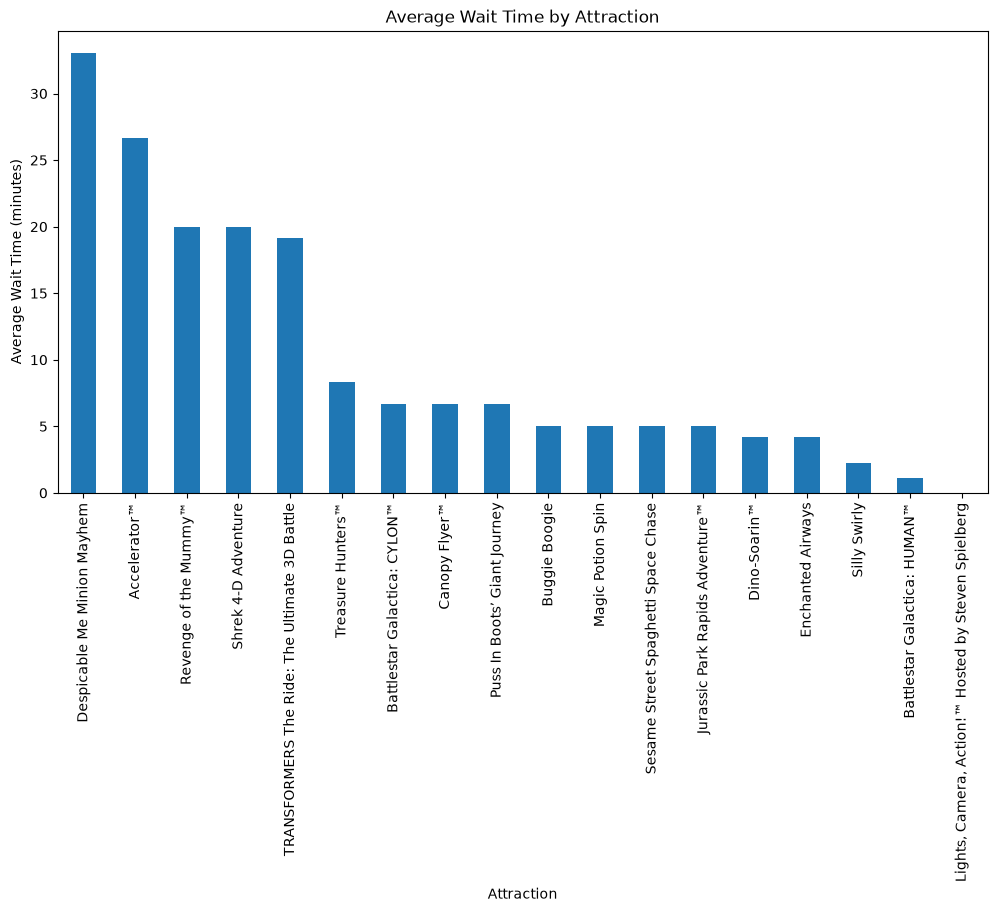

In [19]:
df.groupby("attraction")["wait_time"].mean().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 6),
    title="Average Wait Time by Attraction",
    ylabel="Average Wait Time (minutes)",
    xlabel="Attraction"
)

## Wait Times Over Time

This section examines how attraction wait times change throughout the observation period.

### Collection Intervals

The time between consecutive data-collection snapshots is examined to verify the regularity of the collection process.

In [20]:
timestamps = df["timestamp"].drop_duplicates().sort_values()

timestamps.diff().dropna()

18    0 days 00:01:13
36    0 days 00:03:36
54    0 days 06:46:01
72    0 days 00:07:00
90    0 days 15:44:01
108   0 days 00:01:00
126   0 days 00:01:01
144   0 days 00:01:00
162   0 days 00:01:01
180   0 days 00:01:01
198   0 days 00:01:00
216   0 days 00:01:01
234   0 days 00:01:00
252   0 days 00:01:01
270   0 days 00:08:49
288   0 days 00:03:01
306   0 days 00:01:18
324   0 days 00:02:49
342   0 days 00:03:55
Name: timestamp, dtype: timedelta64[us]

### Overall Wait Time Over Time

The average wait time across all attractions is calculated for each collection timestamp to show how overall wait times changed during the observation period.

<Axes: title={'center': 'Average Wait Time Over Time'}, xlabel='Time', ylabel='Average Wait Time (minutes)'>

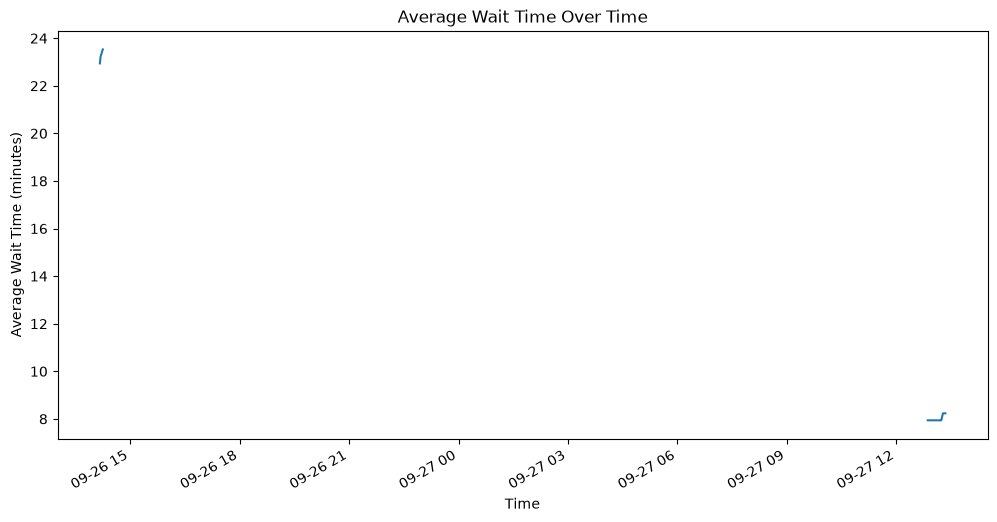

In [21]:
df.groupby("timestamp")["wait_time"].mean().plot(
    kind="line",
    figsize=(12, 6),
    title="Average Wait Time Over Time",
    ylabel="Average Wait Time (minutes)",
    xlabel="Time"
)

### Attraction Trends

Wait-time trends can also be examined by attraction to identify differences in how individual attractions changed over time.

<Axes: title={'center': 'Wait Times by Attraction Over Time'}, xlabel='Time', ylabel='Wait Time (minutes)'>

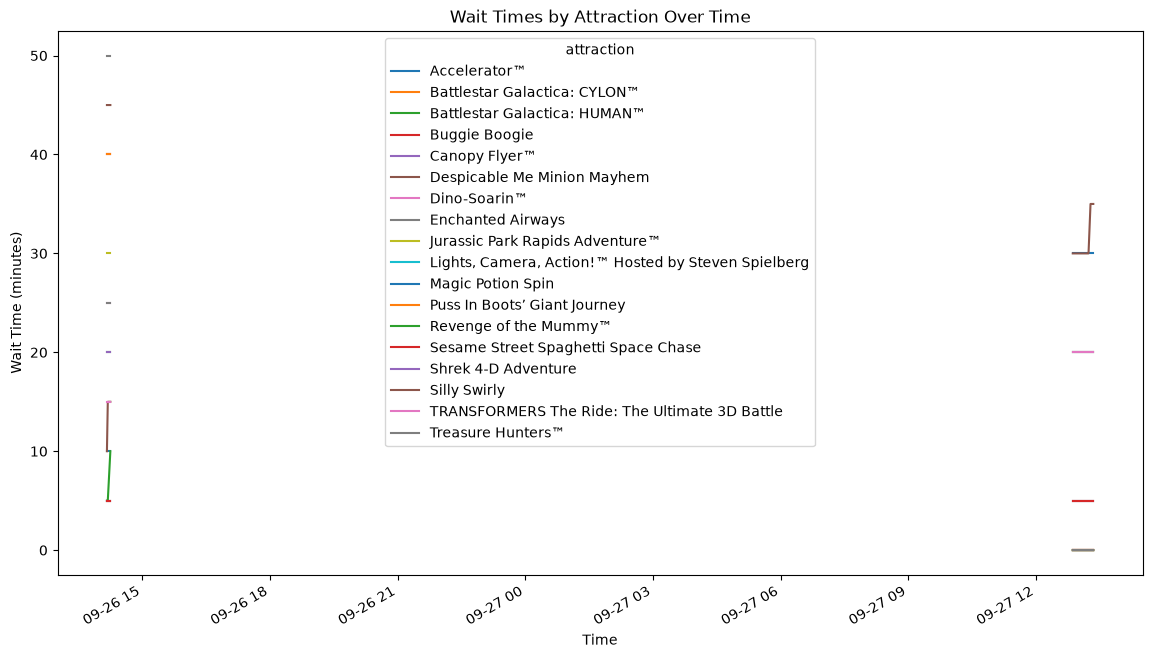

In [22]:
df.pivot(
    index="timestamp",
    columns="attraction",
    values="wait_time"
).plot(
    figsize=(14, 8),
    title="Wait Times by Attraction Over Time",
    ylabel="Wait Time (minutes)",
    xlabel="Time"
)